In [1]:
%pip install -q pandas scikit-learn scipy matplotlib


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import specific tools for hierarchical and density-based clustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

# Configure pandas to show more columns and cleaner numbers
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 4)

# Set a clean visual style for our plots
plt.style.use("seaborn-v0_8-whitegrid")

def plot_cluster_map(points_2d, labels, title, axis=None, x_label="Component 1", y_label="Component 2"):
    """Helper to visualize 2D clusters with distinct colors for each group and black for noise."""
    if axis is None:
        axis = plt.gca()

    unique_labels = sorted(np.unique(labels))
    palette = plt.get_cmap("tab10")
    color_index = 0

    for label in unique_labels:
        mask = labels == label
        if label == -1:
            # Handle noise points specifically for DBSCAN
            axis.scatter(points_2d[mask, 0], points_2d[mask, 1], color="black", s=45, alpha=0.85, label="noise")
        else:
            # Plot standard clusters
            axis.scatter(points_2d[mask, 0], points_2d[mask, 1], color=palette(color_index % 10), s=45, alpha=0.85, label=f"cluster {label}")
            color_index += 1

    axis.set_title(title)
    axis.set_xlabel(x_label)
    axis.set_ylabel(y_label)
    axis.legend()
    axis.grid(alpha=0.25)

def silhouette_details(features, labels):
    """Calculates how well-separated the clusters are."""
    unique_labels = np.unique(labels)
    # We need at least 2 clusters (and not just noise) to compute a meaningful score
    if len(unique_labels) < 2 or len(unique_labels) >= len(labels):
        return np.full(len(labels), np.nan), np.nan

    sample_scores = silhouette_samples(features, labels)
    average_score = silhouette_score(features, labels)
    return sample_scores, float(average_score)

def describe_clustering(features, labels, model_name):
    """Summarizes the results of a clustering run into a dictionary."""
    sample_scores, average_score = silhouette_details(features, labels)
    row = {
        "model": model_name,
        "cluster_count": int(len(set(labels)) - (1 if -1 in labels else 0)),
        "noise_points": int(np.sum(labels == -1)),
        "silhouette_score": average_score,
    }
    return row, sample_scores

def estimate_eps_from_k_distance(sorted_distances):
    """Finds the 'elbow' point in the K-distance graph to suggest an optimal eps for DBSCAN."""
    x_values = np.arange(len(sorted_distances), dtype=float)
    points = np.column_stack((x_values, sorted_distances))
    start, end = points[0], points[-1]

    # Calculate the distance of every point to the line connecting start and end
    line_vector = (end - start) / np.linalg.norm(end - start)
    projected_points = start + np.outer((points - start) @ line_vector, line_vector)
    distances_to_line = np.linalg.norm(points - projected_points, axis=1)

    # The point furthest from the straight line is our 'elbow'
    elbow_index = int(np.argmax(distances_to_line))
    return float(sorted_distances[elbow_index]), elbow_index

In [3]:
from sklearn.datasets import load_iris

# Load the classic Iris dataset for a real-world test
iris_bundle = load_iris(as_frame=True)
iris_features = iris_bundle.data.copy()
iris_target = iris_bundle.target.copy()
iris_names = iris_bundle.target_names

# Scale the data (crucial for distance-based clustering)
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(iris_features)

# Use PCA to squash 4D data into 2D so we can plot it easily
pca = PCA(n_components=2)
X_iris_pca = pca.fit_transform(X_iris_scaled)

print("Original Iris feature shape:", iris_features.shape)
display(iris_features.head())

Original Iris feature shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


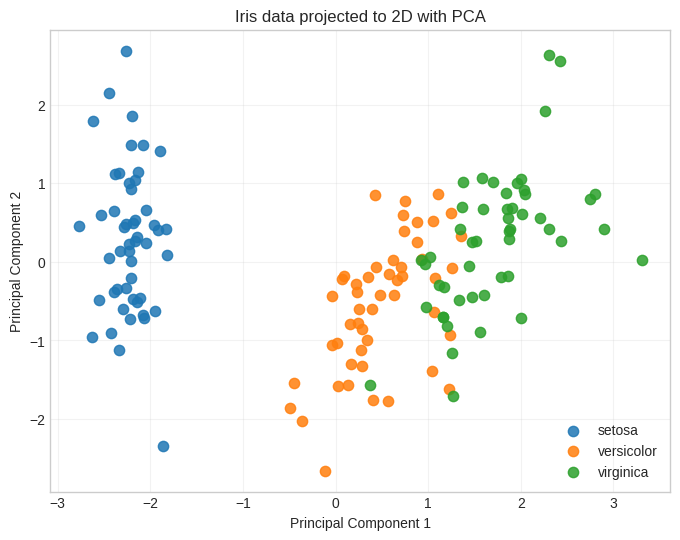

In [4]:
# Plot the ground truth classes using our PCA projection
plt.figure(figsize=(8, 6))
for class_id, class_name in enumerate(iris_names):
    mask = iris_target.to_numpy() == class_id
    plt.scatter(X_iris_pca[mask, 0], X_iris_pca[mask, 1], s=55, alpha=0.85, label=class_name)

plt.title("Iris data projected to 2D with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

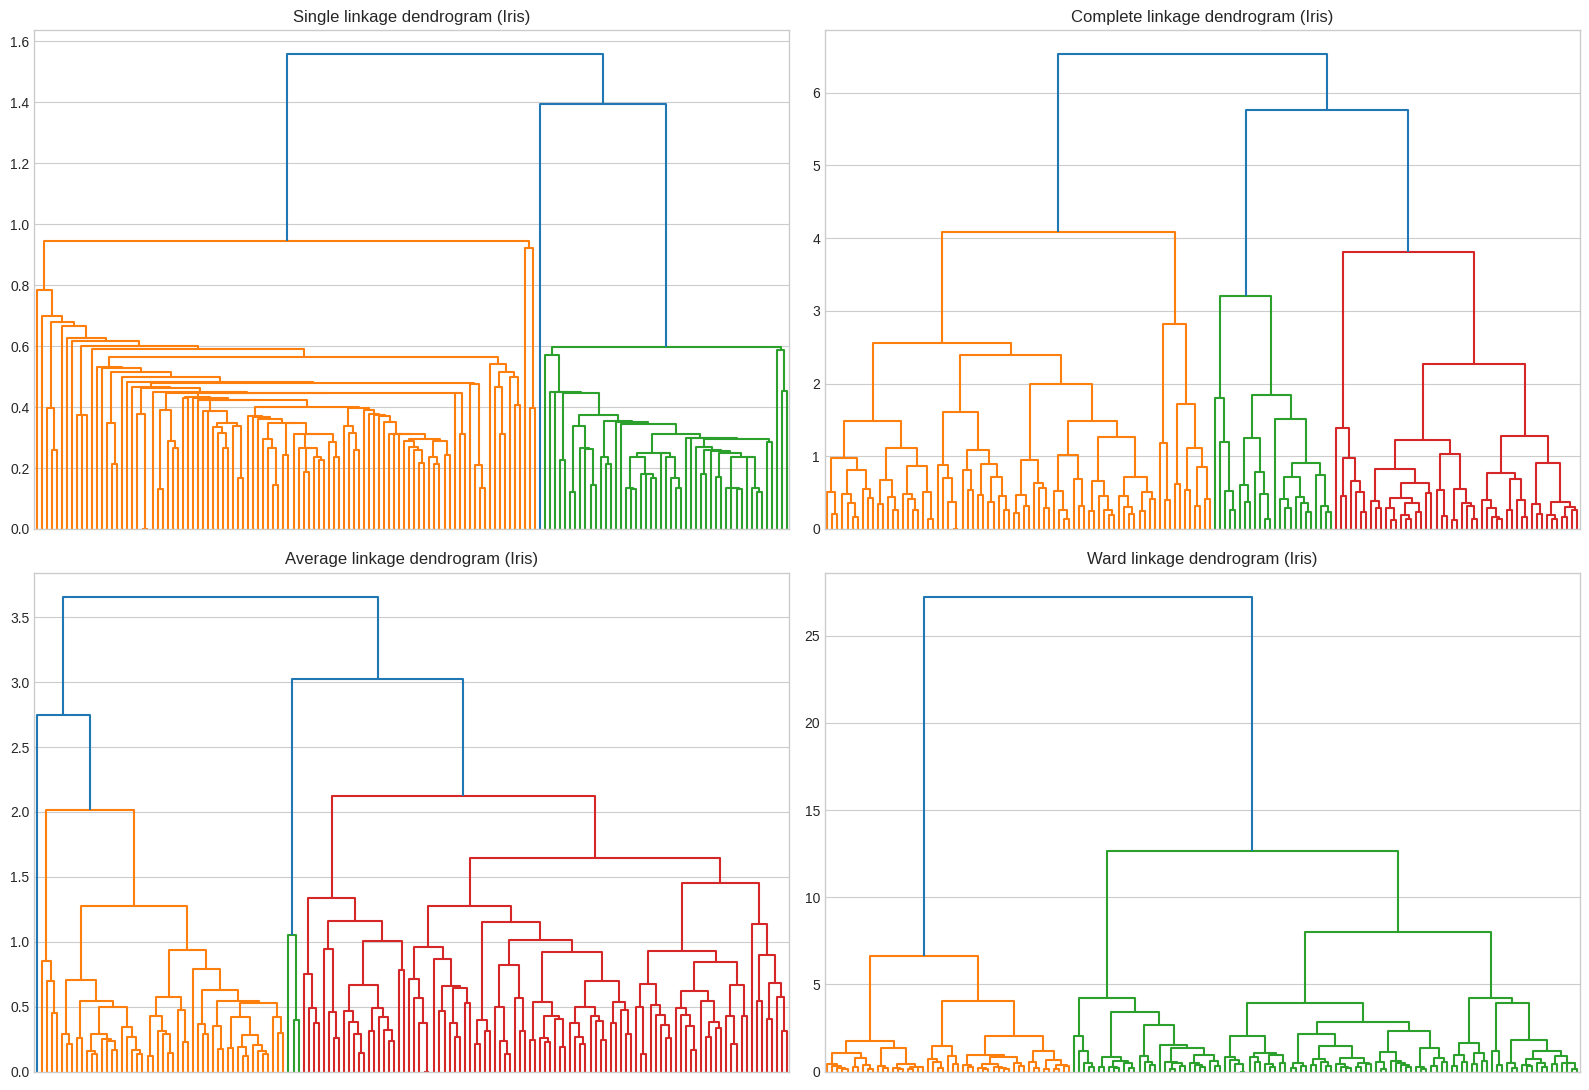

In [6]:
# Run hierarchical linkage again, this time on the real Iris data
linkage_methods = ["single", "complete", "average", "ward"]
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for axis, method in zip(axes.ravel(), linkage_methods):
    linkage_matrix = linkage(X_iris_scaled, method=method)
    dendrogram(linkage_matrix, ax=axis, no_labels=True, color_threshold=None)
    axis.set_title(f"{method.title()} linkage dendrogram (Iris)")

plt.tight_layout()
plt.show()

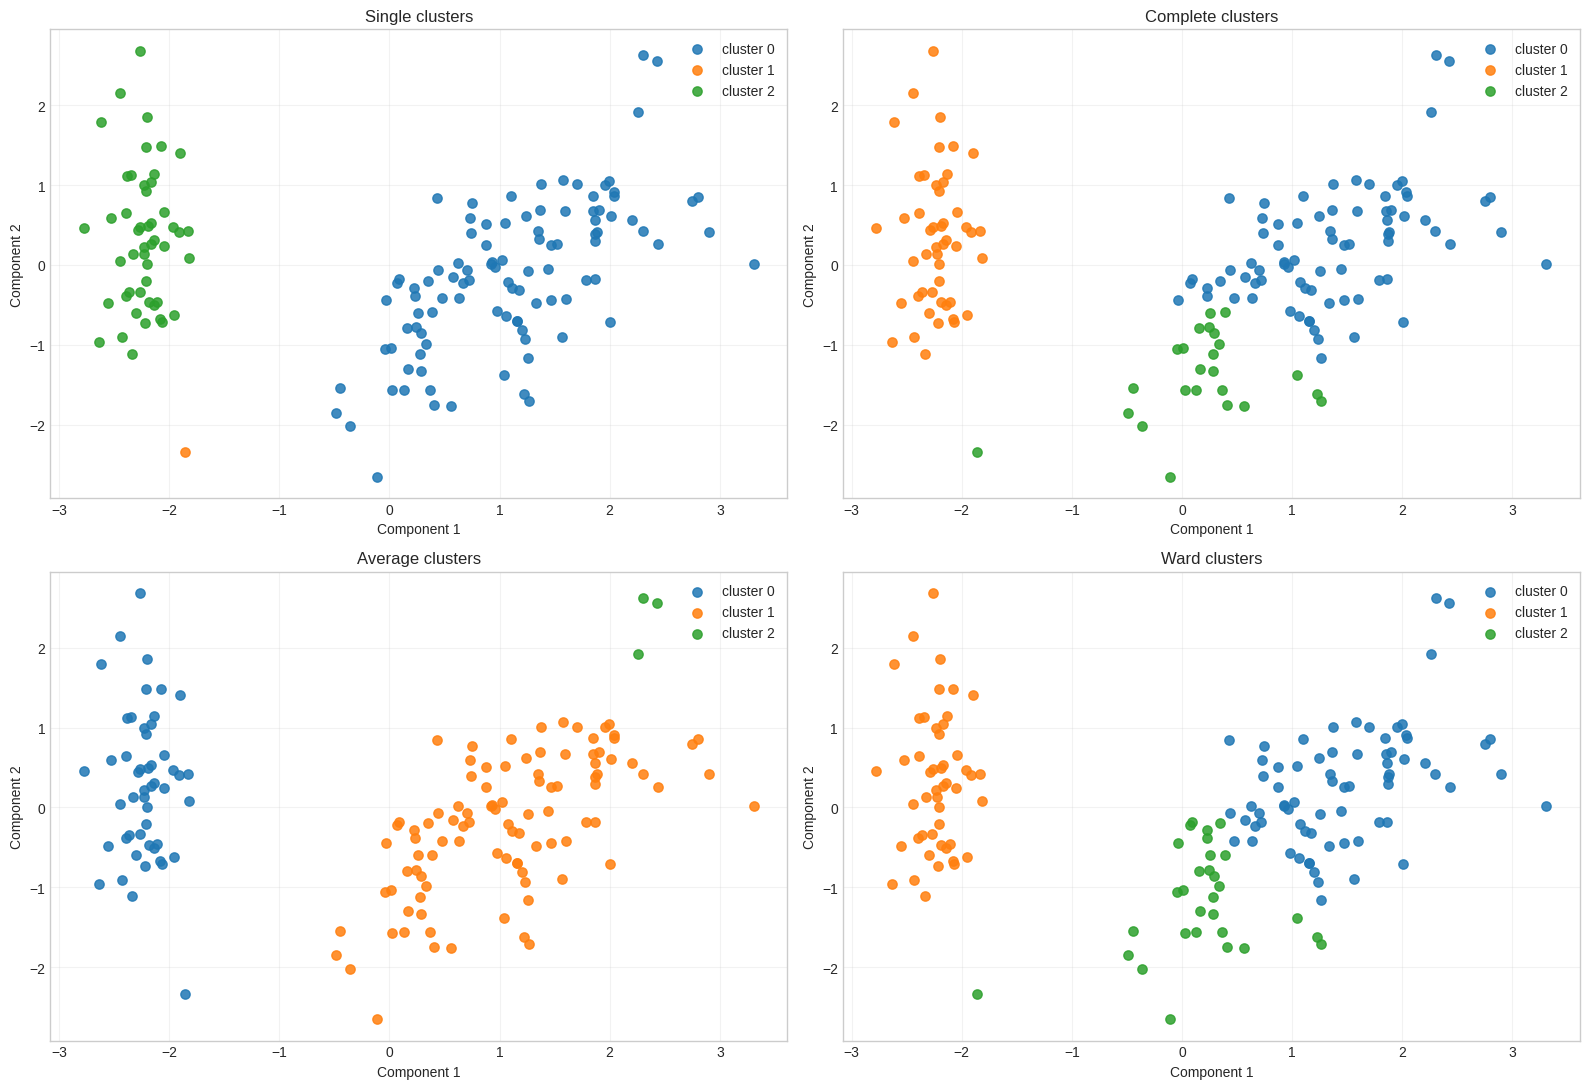

,model,cluster_count,noise_points,silhouette_score
0,Hierarchical - single,3,0,0.5046
2,Hierarchical - average,3,0,0.4803
1,Hierarchical - complete,3,0,0.4496
3,Hierarchical - ward,3,0,0.4467


In [7]:
hierarchical_rows_iris = []
hierarchical_sample_scores_iris = {}

# Group Iris data into 3 clusters (since we know there are 3 species)
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for axis, method in zip(axes.ravel(), linkage_methods):
    model = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = model.fit_predict(X_iris_scaled)

    plot_cluster_map(X_iris_pca, labels, title=f"{method.title()} clusters", axis=axis)

    row, scores = describe_clustering(X_iris_scaled, labels, f"Hierarchical - {method}")
    hierarchical_rows_iris.append(row)
    hierarchical_sample_scores_iris[f"{method}_sample_silhouette"] = scores

plt.tight_layout()
plt.show()
display(pd.DataFrame(hierarchical_rows_iris).sort_values("silhouette_score", ascending=False))

In [8]:
# Show statistical breakdown of how happy each sample is in its cluster for Iris
hierarchical_silhouette_df_iris = pd.DataFrame(hierarchical_sample_scores_iris)
display(hierarchical_silhouette_df_iris.describe().T[["mean", "min", "max"]])

,mean,min,max
single_sample_silhouette,0.5046,-0.3825,0.7153
complete_sample_silhouette,0.4496,-0.2989,0.7438
average_sample_silhouette,0.4803,-0.2350,0.7945
ward_sample_silhouette,0.4467,-0.2304,0.7340


In [9]:
# Tuning DBSCAN for Iris
min_samples_iris = X_iris_scaled.shape[1] + 1
nn_model_iris = NearestNeighbors(n_neighbors=min_samples_iris)
distances_iris, _ = nn_model_iris.fit(X_iris_scaled).kneighbors(X_iris_scaled)
k_distances_iris = np.sort(distances_iris[:, -1])

suggested_eps_iris, _ = estimate_eps_from_k_distance(k_distances_iris)

# Grid search for the best radius on Iris
eps_candidates_iris = np.unique(np.round(np.linspace(max(0.1, suggested_eps_iris * 0.55), suggested_eps_iris * 1.45, 10), 3))
search_rows_iris = []
for eps in eps_candidates_iris:
    labels = DBSCAN(eps=float(eps), min_samples=min_samples_iris).fit_predict(X_iris_scaled)
    row, _ = describe_clustering(X_iris_scaled, labels, f"DBSCAN eps={eps}")
    row["eps"] = float(eps)
    search_rows_iris.append(row)

display(pd.DataFrame(search_rows_iris).sort_values("eps"))

,model,cluster_count,noise_points,silhouette_score,eps
0,DBSCAN eps=0.416,5,63,0.0619,0.416
1,DBSCAN eps=0.492,2,36,0.3419,0.492
2,DBSCAN eps=0.568,2,29,0.3880,0.568
3,DBSCAN eps=0.643,2,15,0.4741,0.643
4,DBSCAN eps=0.719,2,6,0.5234,0.719
5,DBSCAN eps=0.795,2,4,0.5217,0.795
6,DBSCAN eps=0.87,2,4,0.5217,0.870
7,DBSCAN eps=0.946,2,4,0.5217,0.946
8,DBSCAN eps=1.022,2,3,0.5383,1.022
9,DBSCAN eps=1.097,2,2,0.5518,1.097


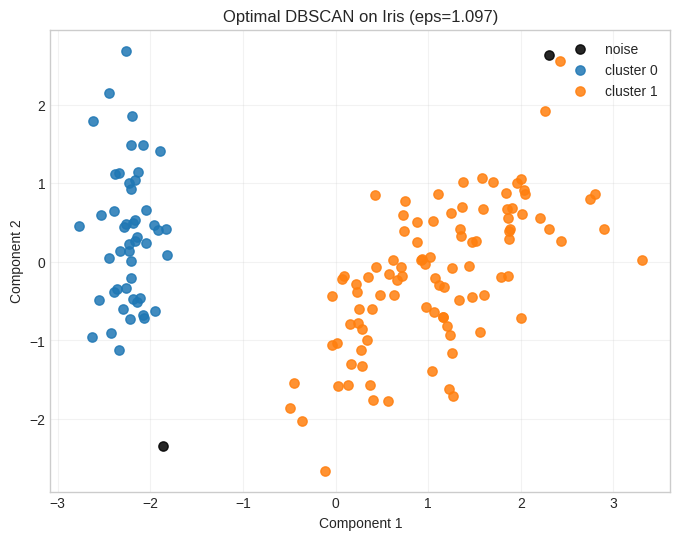

In [10]:
# Select and plot the best DBSCAN configuration for Iris
valid_dbscan_iris = pd.DataFrame(search_rows_iris).query("cluster_count >= 2").dropna()
best_dbscan_iris = valid_dbscan_iris.sort_values(["silhouette_score", "noise_points"], ascending=[False, True]).iloc[0]

best_eps_iris = float(best_dbscan_iris["eps"])
dbscan_iris_labels = DBSCAN(eps=best_eps_iris, min_samples=min_samples_iris).fit_predict(X_iris_scaled)

plt.figure(figsize=(8, 6))
plot_cluster_map(X_iris_pca, dbscan_iris_labels, title=f"Optimal DBSCAN on Iris (eps={best_eps_iris:.3f})")
plt.show()

In [11]:
# Final ranking: How did hierarchical clustering compare to DBSCAN on the Iris dataset?
iris_comparison = pd.concat(
    [pd.DataFrame(hierarchical_rows_iris), pd.DataFrame([describe_clustering(X_iris_scaled, dbscan_iris_labels, f"DBSCAN (eps={best_eps_iris:.3f})")[0]])],
    ignore_index=True
).sort_values("silhouette_score", ascending=False)

display(iris_comparison)

,model,cluster_count,noise_points,silhouette_score
4,DBSCAN (eps=1.097),2,2,0.5518
0,Hierarchical - single,3,0,0.5046
2,Hierarchical - average,3,0,0.4803
1,Hierarchical - complete,3,0,0.4496
3,Hierarchical - ward,3,0,0.4467
